# Taylor and Chebyshev (Dense) Models for Factorable Functions

A $q$th-order Taylor model $(\mathcal{P}_{f,\mathbf{X}}^{q},\mathcal{R}_{f,\mathbf{X}}^{q})$ of a multivariate function $f:{\bf X}\to\mathbb{R}$ that is (at least) $(q+1)$-times continuously differentiable on the interval domain ${\bf X}\in\mathbb{IR}^n$, consists of the $q^{\rm th}$-order multivariate Taylor polynomial $\mathcal P^q_{f,{\bf X}}(\boldsymbol{x}) \coloneqq \sum_{|\kappa|\leq q} a_\kappa ({\bf x}-\hat{\bf x})^\kappa$, expanded around a point $\hat{\bf x}\in {\bf X}$, added to a remainder term $\mathcal{R}_{f,{\bf X}}^q$, so that
\begin{align}
\forall {\bf x}\in {\bf X}, \quad f({x}) - \mathcal{P}_{f,{\bf X}}^q({x}-\hat{x}) \in \mathcal{R}_{f,{\bf X}}^q
\end{align}
The polynomial part $\mathcal{P}_{f,{\bf X}}^q$ is propagated symbolically and accounts for functional dependencies, while the remainder term $\mathcal{R}_{f,{\bf X}}^q\in\mathbb{IR}$ is typically propagated using interval analysis ([Neumaier, 2002](https://doi.org/10.1023/A:1023061927787)). This propagation ensures that the remainder term has convergence order (no less than) $q+1$ with respect to the radius of the interval domain $\bf X$ under mild conditions ([Bompadre et al., 2012](https://doi.org/10.1007/s10898-012-9998-9)).

Similar to Taylor models, Chebyshev models ([Dzetkulič, 2015](https://doi.org/10.1007/s11075-014-9889-x); [Rajyaguru et al., 2016](https://doi.org/10.1007/s10898-016-0474-9)) are estimators made by the sum of a multivariate polynomial in Chebyshev form and a remainder interval providing a bound on the approximation error. Formally, a $q$th-order Chebyshev model of $f$ on $\mathbf{X}$ is any pair $(\mathcal{P}_{f,\mathbf{X}}^{q},\mathcal{R}_{f,\mathbf{X}}^{q})$, where $\mathcal{P}_{f,\mathbf{X}}^{q}:[-1,1]^n\to\mathbb{R}$ with $\mathcal{P}_{f,\mathbf{X}}^{q}(\boldsymbol{\xi}) \coloneqq \sum_{|\kappa|\leq q} a_\kappa T_\kappa(\boldsymbol{\xi})$ is a polynomial approximant of degree $q$, and $\mathcal{R}_{f,\mathbf{X}}^{q}\in\mathbb{IR}$ is a symmetric interval such that
\begin{align}
\forall \boldsymbol{\xi}\in[-1,1]^n, \quad f(\text{mid} \mathbf{X} +\boldsymbol{\xi}\circ\text{rad} \mathbf{X}) - \mathcal{P}_{f,\mathbf{X}}^{q}(\boldsymbol{\xi}) \in \mathcal{R}_{f,\mathbf{X}}^{q}
\end{align}
with $\circ$ denoting the Hadamard product. The variables are scaled in $[-1,1]$ for consistency with the definition and properties of Chebyshev polynomials of the first kind. In practice, the polynomial part $\mathcal{P}_{f,\mathbf{X}}^{q}$ of a Chebyshev model needs need the actual truncated Chebyshev expansion and Chebyshev interpolant of $f$, while still ensuring a convergence order $q+1$ for a sufficiently smooth function $f$ [Rajyaguru et al., 2016](https://doi.org/10.1007/s10898-016-0474-9)). Chebyshev models can provide tighter bounds than their Taylor model counterparts, but this comes at the price of extra computational burden.

The modules `TModel` and `TVar` in PyMC provide a means of computing dense Taylor models for multivariate factorable functions on interval domains $\mathbf{X}\in\mathbb{IR}^n$, while the counterpart modules `CModel` and `CVar` are for computing dense Chebyshev models. Also available in PyMC are modules `SCModel` and `SCVar` for computing sparse Chebyshev models (cf. [Other notebook](./scmodel.ipynb)). 

## Computing Taylor and Chebyshev Models in PyMC

Suppose we want to compute 4th-order Taylor and Chebyshev models of the real-valued function $f(x,y)=x(\exp(x)-y)^2$ for $(x,y)\in [-2,1]\times[-1,2]$. 

In [1]:
def f( x, y ):
    return x*(pymcpp.exp(x)-y)**2
    #return 1.+x-pymcpp.sin(2.*x+3.*y)-pymcpp.cos(3.*x-5.*y)

We start by importing the PyMC library:

In [2]:
import pymcpp

We proceed by defining the environment for 4th-order Chebyshev model. We then define the ranges of both variables $x$ and $y$ (cf. [Other notebook](./interval.ipynb)) and initialize spectral bound variables for $x$ and $y$ of type `pymcpp.TVar` or `pymcpp.CVar` with indices `0` and `1`, respectively:

In [3]:
xI, yI = pymcpp.Interval(-2,1), pymcpp.Interval(-1,2)
N, Q = 2, 4

TEnv = pymcpp.TModel(N,Q)
xT, yT = pymcpp.TVar( TEnv, 0, xI ), pymcpp.TVar( TEnv, 1, yI )

CEnv = pymcpp.CModel(N,Q)
xC, yC = pymcpp.CVar( CEnv, 0, xI ), pymcpp.CVar( CEnv, 1, yI )

With operator overloading, we can simply compute a Taylor model of $f(x,y)$ on $[-2,1]\times[-1,2]$ as:

In [4]:
zT = f( xT, yT )
print( "Dense Taylor model:", zT )

Dense Taylor model: 
   a0    = -5.6743907e-03     0  0
   a1    =  1.0653066e-01     0  1
   a2    = -5.3265330e-02     1  0
   a3    = -5.0000000e-01     0  2
   a4    =  3.9346934e-01     1  1
   a5    = -8.7018554e-02     2  0
   a6    =  0.0000000e+00     0  3
   a7    =  1.0000000e+00     1  2
   a8    = -9.0979599e-01     2  1
   a9    =  2.3778481e-01     3  0
   a10   =  0.0000000e+00     0  4
   a11   =  0.0000000e+00     1  3
   a12   =  0.0000000e+00     2  2
   a13   = -5.0544222e-01     3  1
   a14   =  2.7942705e-01     4  0
   R     =  [-6.9054397e+00, 6.2123279e+00]
   B     =  [-1.9163792e+01, 1.8327271e+01]



We can similarly compute a Chebyshev model of $f(x,y)$ on $[-2,1]\times[-1,2]$ as:

In [5]:
zC = f( xC, yC )
print( "Dense Chebyshev model:", zC )

Dense Chebyshev model: 
   a0    =  2.0248455e-01     0  0
   a1    = -1.9311658e+00     0  1
   a2    =  3.3299674e+00     1  0
   a3    = -5.6250000e-01     0  2
   a4    = -1.3803889e+00     1  1
   a5    =  1.1224854e+00     2  0
   a6    =  0.0000000e+00     0  3
   a7    =  1.6875000e+00     1  2
   a8    = -2.2850179e+00     2  1
   a9    =  7.9153890e-01     3  0
   a10   =  0.0000000e+00     0  4
   a11   =  0.0000000e+00     1  3
   a12   =  0.0000000e+00     2  2
   a13   = -7.7515029e-01     3  1
   a14   =  3.4590814e-01     4  0
   R     =  [-6.8904566e-01, 6.8904566e-01]
   B     =  [-1.2603053e+01, 1.4000743e+01]



Taylor and Chebyshev models bounds can also be propagated through an expression tree (DAG):

In [6]:
DAG  = pymcpp.FFGraph()
X, Y = DAG.add_var( "x" ), DAG.add_var( "y" )

F = f( X, Y )
print( "f(", X.str(), ",", Y.str(), ") = ", F.str() )

[zT2] = DAG.eval( [F], [X,Y], [xT,yT] )
print("Dense Taylor model:", zT2)

[zC2] = DAG.eval( [F], [X,Y], [xC,yC] )
print("Dense Chebyshev model:", zC2)

f( x , y ) =  x * SQR( EXP( x ) - y )
Dense Taylor model: 
   a0    = -5.6743907e-03     0  0
   a1    =  1.0653066e-01     0  1
   a2    = -5.3265330e-02     1  0
   a3    = -5.0000000e-01     0  2
   a4    =  3.9346934e-01     1  1
   a5    = -8.7018554e-02     2  0
   a6    =  0.0000000e+00     0  3
   a7    =  1.0000000e+00     1  2
   a8    = -9.0979599e-01     2  1
   a9    =  2.3778481e-01     3  0
   a10   =  0.0000000e+00     0  4
   a11   =  0.0000000e+00     1  3
   a12   =  0.0000000e+00     2  2
   a13   = -5.0544222e-01     3  1
   a14   =  2.7942705e-01     4  0
   R     =  [-6.9054397e+00, 6.2123279e+00]
   B     =  [-1.9163792e+01, 1.8327271e+01]

Dense Chebyshev model: 
   a0    =  2.0248455e-01     0  0
   a1    = -1.9311658e+00     0  1
   a2    =  3.3299674e+00     1  0
   a3    = -5.6250000e-01     0  2
   a4    = -1.3803889e+00     1  1
   a5    =  1.1224854e+00     2  0
   a6    =  0.0000000e+00     0  3
   a7    =  1.6875000e+00     1  2
   a8    = -2.2850179e+

A 3d plot showing the resulting estimators of the function $f$ over the domain $[-2,1]\times[-1,2]$ is shown below. 

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from itertools import product

M = 128
mat_x = np.outer(np.linspace(xI.l, xI.u, M), np.ones(M))
mat_y = np.outer(np.ones(M), np.linspace(yI.l, yI.u, M))

In [8]:
mat_f    = np.ndarray(shape=(M,M))

mat_fTl  = np.outer(np.ones(M), np.ones(M)) * zT.B.l
mat_fTu  = np.outer(np.ones(M), np.ones(M)) * zT.B.u
mat_fTun = np.ndarray(shape=(M,M))
mat_fTov = np.ndarray(shape=(M,M))

mat_fCl  = np.outer(np.ones(M), np.ones(M)) * zC.B.l
mat_fCu  = np.outer(np.ones(M), np.ones(M)) * zC.B.u
mat_fCun = np.ndarray(shape=(M,M))
mat_fCov = np.ndarray(shape=(M,M))

for i,j in product(range(M),range(M)):
    [mat_f[i,j]] = DAG.eval( [F], [X,Y], [mat_x[i,j],mat_y[i,j]] )    
    
    zPTf = zT.P( [mat_x[i,j], mat_y[i,j]] )
    mat_fTun[i,j] = zPTf + zT.R.l
    mat_fTov[i,j] = zPTf + zT.R.u
    
    zPCf = zC.P( [mat_x[i,j], mat_y[i,j]] )
    mat_fCun[i,j] = zPCf + zC.R.l
    mat_fCov[i,j] = zPCf + zC.R.u

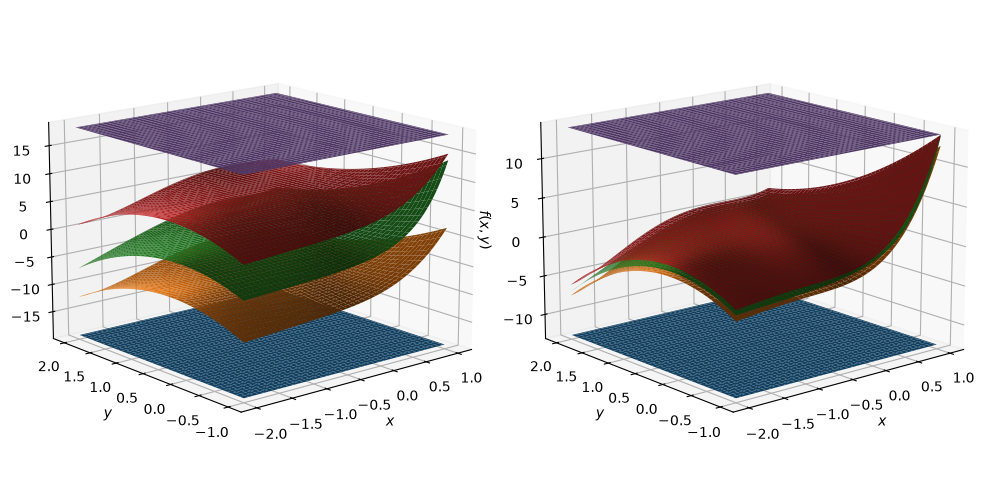

In [9]:
fig, (ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(10,10), subplot_kw=dict(projection='3d'), tight_layout=True)

ax1.view_init(elev=15, azim=230, roll=0)
ax1.plot_surface(mat_x, mat_y, mat_fTl)
ax1.plot_surface(mat_x, mat_y, mat_fTun)
ax1.plot_surface(mat_x, mat_y, mat_f)
ax1.plot_surface(mat_x, mat_y, mat_fTov)
ax1.plot_surface(mat_x, mat_y, mat_fTu)
ax1.set(xlabel="$x$")
ax1.set(ylabel="$y$")
ax1.set(zlabel="$f(x,y)$")

ax2.view_init(elev=15, azim=230, roll=0)
ax2.plot_surface(mat_x, mat_y, mat_fCl)
ax2.plot_surface(mat_x, mat_y, mat_fCun)
ax2.plot_surface(mat_x, mat_y, mat_f)
ax2.plot_surface(mat_x, mat_y, mat_fCov)
ax2.plot_surface(mat_x, mat_y, mat_fCu)
ax2.set(xlabel="$x$")
ax2.set(ylabel="$y$")
ax2.set(zlabel="$f(x,y)$")

plt.savefig("cmodel.png", dpi=300, bbox_inches="tight", pad_inches=0.25)